In [1]:
import ot
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors
from sklearn.cluster import MiniBatchKMeans
import math
import scipy
from scipy.spatial import cKDTree
from scipy import integrate
from scipy import interpolate
from scipy.spatial import Delaunay
from scipy.spatial import Voronoi
from itertools import product
import torch
torch.manual_seed(100000)
import torch.nn as nn
import torch.optim as optim
import pysindy as ps



/homes/yinonghyn/.local/lib/python3.10/site-packages/pysindy/feature_library/base.py:40: DeprecationWarning: Library ensembling is no longer performed by feature libraries.  Use EnsemblingOptimizer to fit an ensemble model.
  warnings.warn(


In [2]:
#settings
start = np.array((0., 1., 1.05))
dt = 0.01
subset_size = 50 #cell number
slope = 1#parameter in weight computation
traj_length = int(1e6)#length of trajectory
noise_level = 0.3
sample_size = int(5000)
simulation_t = int(2e4)
# Define the Lorenz-63 System
def Lorenz(x):
    x = x.T
    dx = 10 * (x[1] - x[0])
    dy = x[0] * (28 - x[2]) - x[1]
    dz = x[0] * x[1] - (8/3) * x[2]
    f = np.array((dx, dy, dz)).T
    return f

 #trajectory simulation (Euler's method)
def traj(length, starts = start, model = Lorenz):
    x = starts
    traj = np.zeros((length,len(starts)))
    traj[0] = np.array(x)
    for timestep in range(length-1):

        x = x + dt * model(x)

        traj[timestep+1] = np.array(x)

    return traj

def invariant_measure(matrix):
    N = len(matrix)
    rhs = (-1) * (epsilon/N) * torch.ones(N)
    rho = torch.linalg.solve(((1 - epsilon) * matrix - torch.eye(N)),rhs)
    return rho
class W2Loss(torch.autograd.Function):#MAT
    @staticmethod
    def forward(ctx, U_net):
        U_net_np = U_net.detach().numpy()
        cost_cols,grad = np.zeros(subset_size),np.zeros((subset_size,subset_size))
        costM = ot.dist(np.arange(subset_size).reshape(-1, 1), np.arange(subset_size).reshape(-1, 1))
        for col in range(subset_size):
            _, log = ot.emd(U_true_np[:,col], U_net_np[:,col], costM, log=True)
            cost_cols[col],grad[col] = log['cost'],log["v"]
        loss,grad = np.sum(cost_cols),grad.T
        grad_tensor = torch.tensor(grad, dtype=U_net.dtype)
        ctx.save_for_backward(grad_tensor)
        return torch.tensor(loss, dtype=U_net.dtype)
    @staticmethod
    def backward(ctx, grad_output):
        grad_tensor, = ctx.saved_tensors  # Unpack gradient
        return grad_tensor.reshape(subset_size,subset_size)

In [3]:
trajectory_clean = traj(traj_length)

In [4]:
trajectory = trajectory_clean + np.random.normal(0,noise_level,((traj_length,3)))#loooooooong trajectory
trajectory = trajectory[int(1e4):]

#a random chuck of data
rand_start = np.random.randint(1, len(trajectory)-sample_size)
randpts = torch.tensor(trajectory[rand_start:rand_start+sample_size],dtype = torch.float)
Trandpts = torch.tensor(trajectory[rand_start+1:rand_start+1+sample_size],dtype = torch.float)

#normalization
M_scale = torch.max(torch.abs(randpts))
randpts /= M_scale
Trandpts /= M_scale
M_scale_torch = M_scale
#Voronoi cell center
Voronoi_centers = MiniBatchKMeans(n_clusters=subset_size).fit(randpts).cluster_centers_

tree = cKDTree(Voronoi_centers)
Voronoi_centers = torch.tensor(Voronoi_centers,dtype = torch.float)

#count points in each cell
def count_occurrences(arr):
    unique_elements, counts = np.unique(arr, return_counts=True)
    result_array = np.zeros(np.max(unique_elements) + 1, dtype=int)
    result_array[unique_elements] += counts
    return result_array

relu = nn.ReLU()

def decay(x):
    return relu(1-slope*x)
def w(xs):
    dists =  torch.cdist(xs, Voronoi_centers, p =2)
    pre_w = decay(dists)
    return  pre_w / torch.sum(pre_w, dim=1,keepdim = True)


def Ulam(points,Tpoints):
    mat = torch.zeros((subset_size, subset_size))
    #before normalization
    with torch.no_grad():
          randpts_idxs = torch.tensor(tree.query(points.detach().numpy())[1], dtype=torch.int)
    weights = w(Tpoints)
    mat.index_add_(0, randpts_idxs, weights)
    mat = (mat.T)/mat.sum(dim = 1)
    return mat
U_true = Ulam(randpts,Trandpts)
U_true_np = U_true.detach().cpu().numpy()

/homes/yinonghyn/.local/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1930: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=3)


In [5]:
def Lorenz_vec(x):
    dx = 10 * (x[:,1] - x[:,0])
    dy = x[:,0] * (28 - x[:,2]) - x[:,1]
    dz = x[:,0] * x[:,1] - (8/3) * x[:,2]
    return torch.cat((dx.reshape(len(x),1),dy.reshape(len(x),1),dz.reshape(len(x),1)),dim = 1)

In [6]:



torch.manual_seed(100000)
net1 = nn.Sequential(
            nn.Linear(3, 100),
            nn.Tanh(),
            nn.Linear(100, 100),
            nn.Tanh(),
            nn.Linear(100, 100),
            nn.Tanh(),
            nn.Linear(100, 3))

optimizer1 = optim.Adam(net1.parameters(),lr = 1e-3)
# optimizer2 = optim.Adam(net2.parameters(),lr = 1e-3)
# net2.train()
N_iters = 10000

net1.train()
loss1 = []
invert_variables = [0,1,2]

net1_randpts = randpts.clone()  # safe copy, avoid modifying original tensor

V_field = Lorenz_vec(net1_randpts*M_scale)/M_scale
V_field[:,invert_variables] = net1(net1_randpts)[:,invert_variables]
net1_randpts = net1_randpts+dt* V_field
U_net = Ulam(randpts,net1_randpts)
initial_L1 = W2Loss.apply(U_net)

Iteration 0, Loss(Ours): 1.3547642230987549


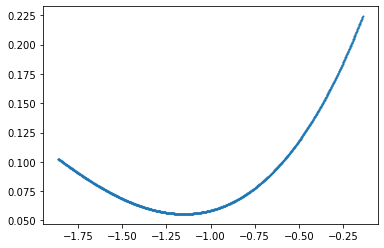

Iteration 500, Loss(Ours): 0.07141967862844467
Iteration 1000, Loss(Ours): 0.041861969977617264
Iteration 1500, Loss(Ours): 0.03353012725710869
Iteration 2000, Loss(Ours): 0.029081571847200394
Iteration 2500, Loss(Ours): 0.028728244826197624
Iteration 3000, Loss(Ours): 0.03092227689921856
Iteration 3500, Loss(Ours): 0.027443768456578255
Iteration 4000, Loss(Ours): 0.02659044787287712
Early stopping at iteration 4000, Loss: 0.02659044787287712


In [7]:
for i in range(N_iters):
    # Zero gradients for each optimizer
    optimizer1.zero_grad()
    net1_randpts = randpts
    V_field = Lorenz_vec(net1_randpts*M_scale)/M_scale
    V_field[:,invert_variables] = net1(net1_randpts)[:,invert_variables]
    net1_randpts = net1_randpts+dt* V_field
    U_net = Ulam(randpts,net1_randpts)
    L1 = W2Loss.apply(U_net)
    L1.backward()
    optimizer1.step()
    loss1.append(L1.item()) 

    with torch.no_grad():
        if i % 500 == 0:
            print(f'Iteration {i}, Loss(Ours): {L1.item()}')
            if L1.item() < 0.02  * initial_L1:
                print(f"Early stopping at iteration {i}, Loss: {L1.item()}")
                break
    # Visualization every 5000 iterations
    if i % 5000 == 0:
        x1 = torch.tensor(randpts[0], dtype=torch.float).reshape(1, 3)
        # x2 = x1
        vals1= [x1.detach().numpy().flatten()]
        for _ in range(int(1e3)-1):
            V_field = Lorenz_vec(x1*M_scale)/M_scale
            V_field[:,invert_variables] = net1(x1)[:,invert_variables]
            x1 = x1 + V_field*dt
                
            vals1.append(x1.detach().numpy().flatten())

        
        vals1= np.array(vals1)
        plt.scatter(vals1[:, 0], vals1[:, 2], s=1)
        plt.show()



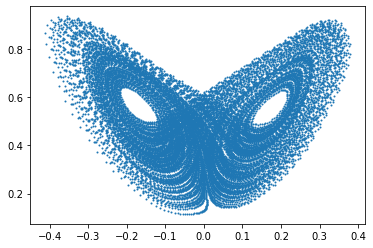

In [8]:
x1 = torch.tensor(randpts[0], dtype=torch.float).reshape(1, 3)
vals1 = [x1.detach().numpy().flatten()]
for _ in range(simulation_t-1):

    V_field = Lorenz_vec(x1*M_scale)/M_scale
    V_field[:,invert_variables] = net1(x1)[:,invert_variables]
    x1 = x1 + V_field*dt
    vals1.append(x1.detach().numpy().flatten())
vals1 = np.array(vals1)
plt.scatter(vals1[:, 0], vals1[:, 2], s=1)
plt.show()

In [9]:

torch.manual_seed(100000)
net2 = nn.Sequential(
            nn.Linear(3, 100),
            nn.Tanh(),
            nn.Linear(100, 100),
            nn.Tanh(),
            nn.Linear(100, 100),
            nn.Tanh(),
            nn.Linear(100, 3))


optimizer2 = optim.Adam(net2.parameters(),lr = 1e-3)
net2.train()


loss2 = []
net2_randpts = randpts.clone()  
V_field2 = Lorenz_vec(net2_randpts*M_scale)/M_scale
V_field2[:,invert_variables] = net2(net2_randpts)[:,invert_variables]
net2_randpts = net2_randpts+dt* V_field2
U_net = Ulam(randpts,net2_randpts)
initial_L2 = torch.mean((net2_randpts - Trandpts) ** 2)

Iteration 0, Loss(Ours): 0.00025368441129103303


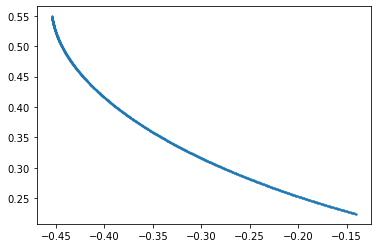

Iteration 500, Loss(Ours): 7.33272754587233e-05
Iteration 1000, Loss(Ours): 6.833938095951453e-05
Iteration 1500, Loss(Ours): 6.67838758090511e-05
Iteration 2000, Loss(Ours): 6.613657023990527e-05
Iteration 2500, Loss(Ours): 6.576628948096186e-05
Iteration 3000, Loss(Ours): 6.547998054884374e-05
Iteration 3500, Loss(Ours): 6.526810466311872e-05
Iteration 4000, Loss(Ours): 6.505275814561173e-05
Iteration 4500, Loss(Ours): 6.484656478278339e-05
Iteration 5000, Loss(Ours): 6.462917372118682e-05


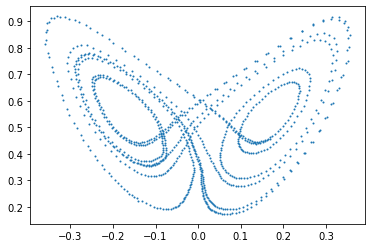

Iteration 5500, Loss(Ours): 6.441395817091689e-05
Iteration 6000, Loss(Ours): 6.419621786335483e-05
Iteration 6500, Loss(Ours): 6.39665377093479e-05
Iteration 7000, Loss(Ours): 6.372760253725573e-05
Iteration 7500, Loss(Ours): 6.350388866849244e-05
Iteration 8000, Loss(Ours): 6.333613418973982e-05
Iteration 8500, Loss(Ours): 6.321680848486722e-05
Iteration 9000, Loss(Ours): 6.285056588239968e-05
Iteration 9500, Loss(Ours): 6.273709004744887e-05


In [10]:
for i in range(N_iters):
    # Zero gradients for each optimizer
    optimizer2.zero_grad()

    
    net2_randpts = randpts

    V_field2 = net2(net2_randpts)
    net2_randpts = net2_randpts+dt*V_field2


    L2 = torch.mean((net2_randpts - Trandpts) ** 2)
    L2.backward()
    optimizer2.step()
    loss2.append(L2.item())
    

    # Logging
    with torch.no_grad():
        if i % 500 == 0:
            print(f'Iteration {i}, Loss(Ours): {L2.item()}')
            if L2.item() < 0.02  * initial_L2:
                print(f"Early stopping at iteration {i}, Loss: {L2.item()}")
                break
        
    # Visualization
    if i % 5000 == 0:
        x2 = torch.tensor(randpts[0], dtype=torch.float).reshape(1, 3)
        vals2 = [x2.detach().numpy().flatten()]
        for _ in range(int(1e3)-1):

            V_field2 = net2(x2)
            x2 = x2 + V_field2*dt
            vals2.append(x2.detach().numpy().flatten())
        vals2 = np.array(vals2)
        plt.scatter(vals2[:, 0], vals2[:, 2], s=1)
        plt.show()

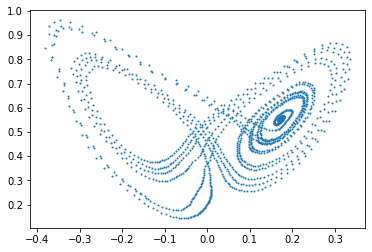

In [11]:
x2 = torch.tensor(randpts[0], dtype=torch.float).reshape(1, 3)
vals2 = [x2.detach().numpy().flatten()]
for _ in range(simulation_t-1):


    V_field2 = net2(x2)
    x2 = x2 + V_field2*dt
    vals2.append(x2.detach().numpy().flatten())
vals2 = np.array(vals2)
plt.scatter(vals2[:, 0], vals2[:, 2], s=1)
plt.show()

In [12]:
#SINDy
sindy_model = ps.SINDy(feature_library=ps.PolynomialLibrary(degree=6))
sindy_model.fit(randpts, t=dt)



/homes/yinonghyn/.local/lib/python3.10/site-packages/pysindy/feature_library/base.py:40: DeprecationWarning: Library ensembling is no longer performed by feature libraries.  Use EnsemblingOptimizer to fit an ensemble model.
  warnings.warn(


SINDy(differentiation_method=FiniteDifference(),
      feature_library=PolynomialLibrary(degree=6),
      feature_names=['x0', 'x1', 'x2'], optimizer=STLSQ())

In [13]:
x0 = [randpts[:, 0][0], randpts[:, 1][0],randpts[:, 2][0]]  # Initial values from the data
vals_sindy = [x0]  # To store the trajectory
x = np.array(x0)
# Manual Euler integration
try:
    for _ in range(simulation_t-1):  
        try:
            x = x + dt * sindy_model.predict(np.array(x).reshape(1, -1)).flatten()
        except ValueError as e:
            print(f"ValueError occurred: {e}")
            raise  # Raise the error to exit both loops
        vals_sindy.append(x)
except ValueError:
    print(f"Stopped simulation at outer iteration {_} due to an error.")

vals_sindy = np.array(vals_sindy)


ValueError occurred: Input X contains infinity or a value too large for dtype('float64').
Stopped simulation at outer iteration 441 due to an error.


/homes/yinonghyn/.local/lib/python3.10/site-packages/pysindy/utils/axes.py:83: RuntimeWarning: overflow encountered in reduce
  results = super().__array_ufunc__(ufunc, method, *args, **kwargs)


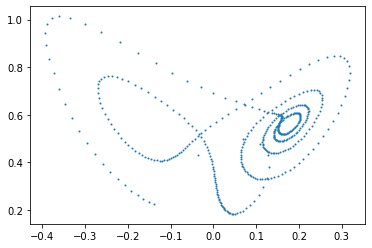

In [14]:

plt.scatter(vals_sindy[:,0][:-4],vals_sindy[:,2][:-4],s = 1)

In [15]:

GT = traj(int(simulation_t), M_scale* randpts[0])

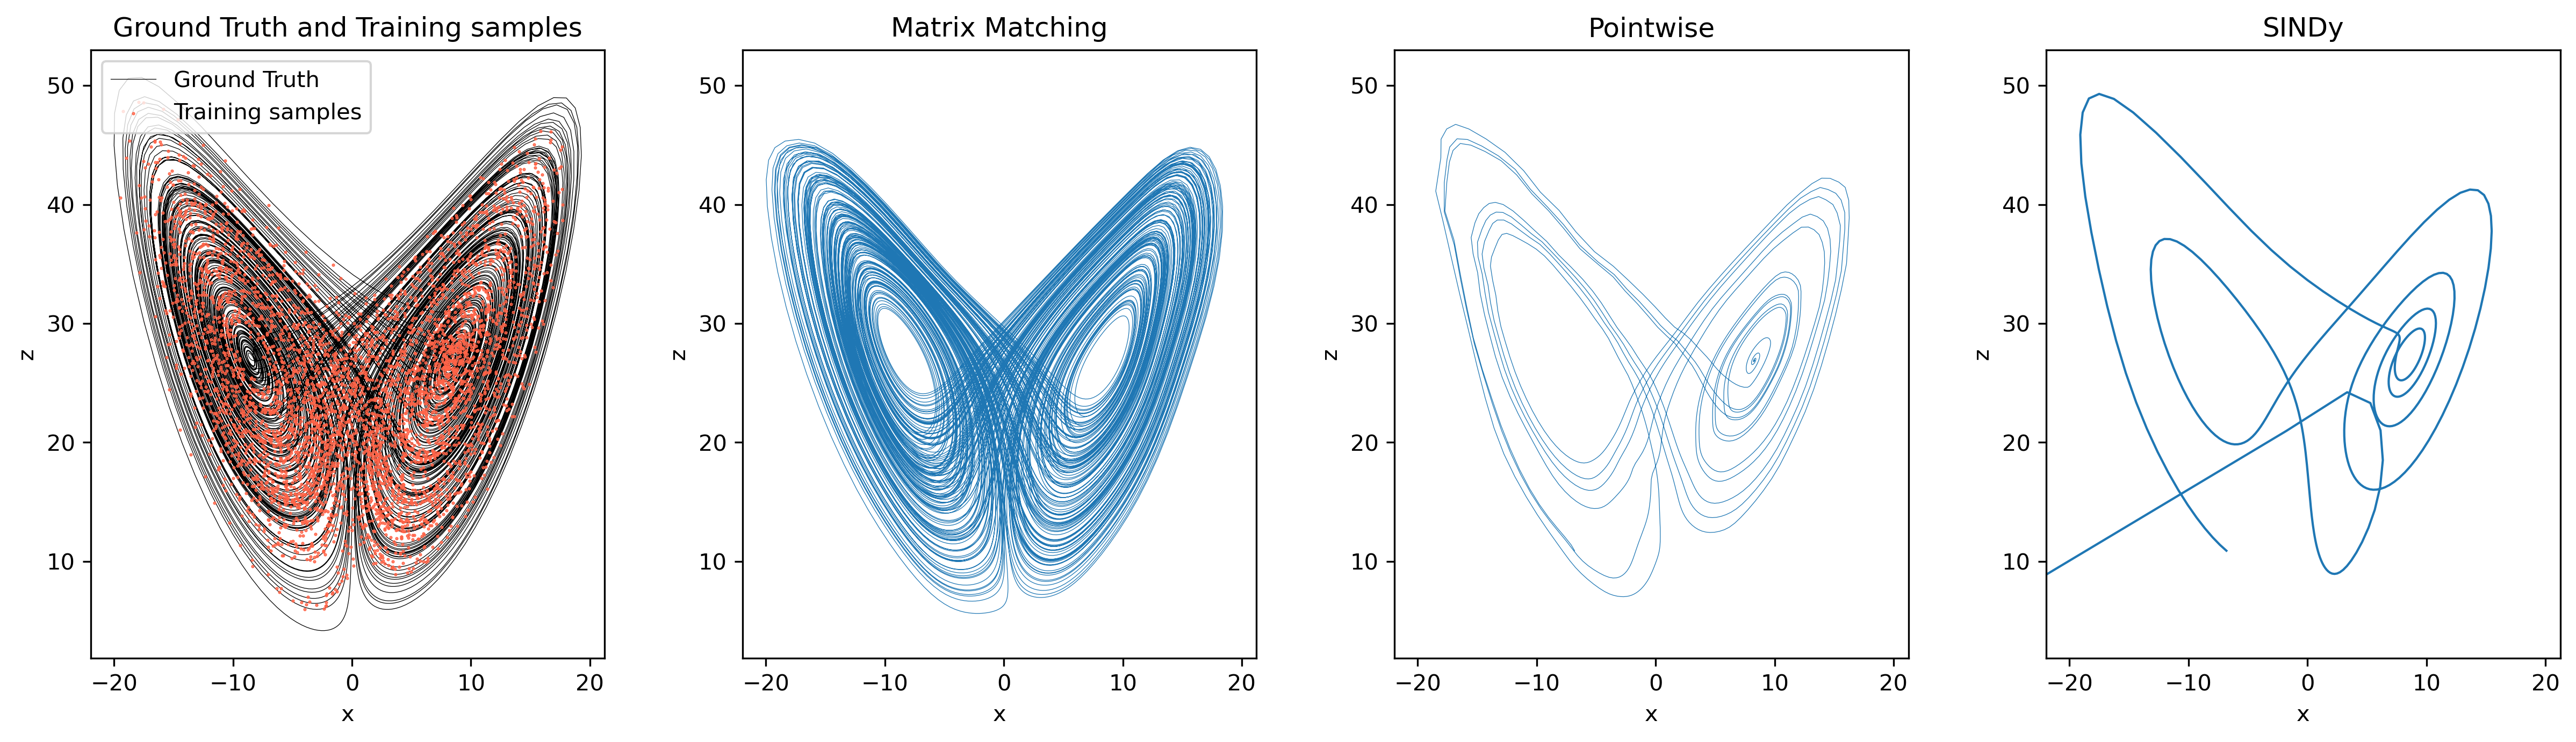

In [16]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5),dpi = 300)

axes[1].plot(M_scale * vals1[:, 0], M_scale * vals1[:, 2], linewidth=0.3)
axes[1].set_title('Matrix Matching')

axes[3].plot(M_scale * vals_sindy[:, 0][:-2], M_scale * vals_sindy[:, 2][:-2], linewidth=1)
axes[3].set_title('SINDy')

axes[2].plot(M_scale * vals2[:, 0], M_scale * vals2[:, 2], linewidth=0.3)
axes[2].set_title('Pointwise')

# Plot ground truth trajectory

axes[0].plot(GT[:, 0], GT[:, 2], label="Ground Truth",c="black", linewidth=0.3, zorder=1)
axes[0].scatter(M_scale * randpts[:, 0], M_scale * randpts[:, 2], s=0.2, c="tomato", alpha = 1,
                label="Training samples", zorder=2)
axes[0].set_title('Ground Truth and Training samples')
axes[0].legend(loc='upper left')


xlim = axes[0].get_xlim()
ylim = axes[0].get_ylim()

for ax in axes:
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_xlabel('x')
    ax.set_ylabel('z')
    ax.set_aspect('equal')
plt.show()